In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telecom_customer_churn_processed.csv')
print(df.shape)
df.head()

(7043, 40)


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Name,SupportTicketCount
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN,Asu Soylu,0
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN,Yankı Arslan,4
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,Abdiş Sezgin,2
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,Evrimer Güçlü,5
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,Ayduru Bilir,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

In [3]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,SupportTicketCount
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056,2.000994
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.736022
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,0.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000,1.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000,2.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,3.000000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,10.000000


In [4]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [5]:
df['Customer Status'].value_counts()
df['Customer Status'].value_counts(normalize=True)

Customer Status
Stayed     0.670169
Churned    0.265370
Joined     0.064461
Name: proportion, dtype: float64

In [12]:
def outlier_summary(column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    
    print(f"--- {column_name} ---")
    print(f"Min: {df[column_name].min()}")
    print(f"Q1 (25%): {Q1}")
    print(f"Medyan (50%): {df[column_name].median()}")
    print(f"Q3 (75%): {Q3}")
    print(f"Max: {df[column_name].max()}")
    print(f"IQR: {IQR}")
    print(f"Alt sınır: {lower_bound:.2f}")
    print(f"Üst sınır: {upper_bound:.2f}")
    print(f"Aykırı değer sayısı: {len(outliers)}")
    print()

for col in ['Monthly Charge', 'Total Revenue', 'Age']:
    outlier_summary(col)

--- Monthly Charge ---
Min: -10.0
Q1 (25%): 30.4
Medyan (50%): 70.05
Q3 (75%): 89.75
Max: 118.75
IQR: 59.35
Alt sınır: -58.63
Üst sınır: 178.78
Aykırı değer sayısı: 0

--- Total Revenue ---
Min: 21.36
Q1 (25%): 605.61
Medyan (50%): 2108.64
Q3 (75%): 4801.145
Max: 11979.34
IQR: 4195.535000000001
Alt sınır: -5687.69
Üst sınır: 11094.45
Aykırı değer sayısı: 21

--- Age ---
Min: 19
Q1 (25%): 32.0
Medyan (50%): 46.0
Q3 (75%): 60.0
Max: 80
IQR: 28.0
Alt sınır: -10.00
Üst sınır: 102.00
Aykırı değer sayısı: 0



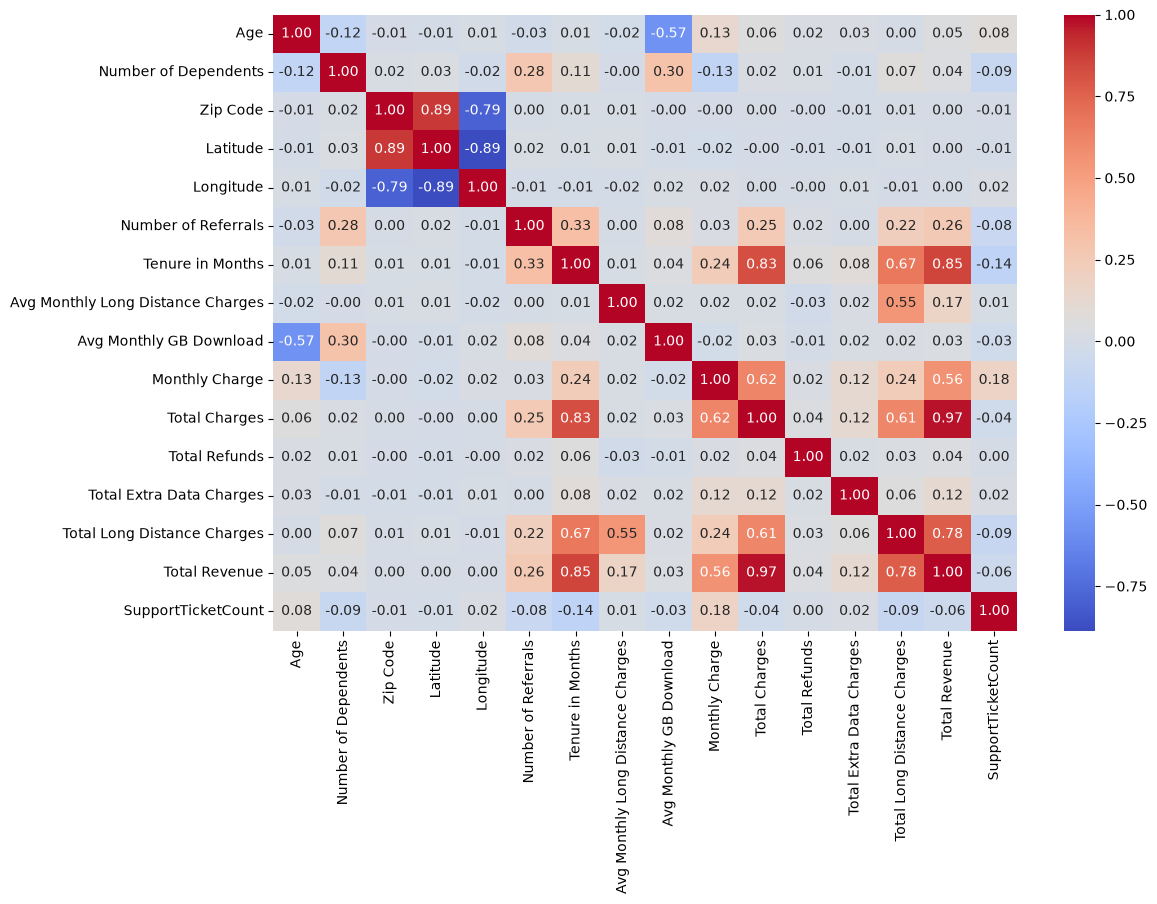

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [9]:
df.groupby('Customer Status')['Monthly Charge'].mean()
df.groupby('Customer Status')['Tenure in Months'].mean()

Customer Status
Churned    17.979133
Joined      1.720264
Stayed     41.041525
Name: Tenure in Months, dtype: float64

In [13]:
df[df['Monthly Charge'] < 0]

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Name,SupportTicketCount
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN,Yankı Arslan,4
32,0052-DCKON,Male,28,Yes,0,Los Angeles,90063,34.044271,-118.185237,9,...,7942.15,0.00,0,2888.82,10830.97,Stayed,NaN,NaN,Eral Güçlü,0
170,0274-JKUJR,Male,21,Yes,2,Los Angeles,90040,33.994524,-118.149953,9,...,465.70,0.00,0,0.00,465.70,Stayed,NaN,NaN,Siper Durmuş,5
232,0361-HJRDX,Female,38,No,0,Sherman Oaks,91403,34.147149,-118.463365,0,...,4539.60,0.00,130,0.00,4669.60,Stayed,NaN,NaN,Fatigül Ülker,1
336,0495-ZBNGW,Male,78,Yes,0,Loma Mar,94021,37.266388,-122.263080,1,...,343.95,0.00,20,33.30,397.25,Churned,Competitor,Competitor offered more data,Sançar Akçay,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6894,9793-WECQC,Male,53,No,0,Foresthill,95631,39.031876,-120.811141,0,...,2192.90,0.00,0,1108.83,3301.73,Stayed,NaN,NaN,Risalet Akgündüz,3
6918,9821-BESNZ,Male,43,No,0,Northridge,91325,34.236683,-118.517588,0,...,6860.60,44.00,0,2179.32,8995.92,Stayed,NaN,NaN,Enginiz Gülen,1
6976,9898-KZQDZ,Female,65,Yes,0,Lee Vining,93541,37.890145,-119.184087,1,...,3640.45,0.00,0,1980.00,5620.45,Churned,Competitor,Competitor had better devices,Gülözge Erdoğan,1
7020,9961-JBNMK,Male,79,No,0,Desert Center,92239,33.889605,-115.257009,0,...,2030.30,10.20,0,887.67,2907.77,Churned,Dissatisfaction,Product dissatisfaction,Halidun Bilgin,3
